In [86]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import uproot
import sys

sys.path.append('/exp/sbnd/data/users/aantonak/SBNDWireModFitting/')

In [ ]:
TPC = 1
PLANE = 2

IDX = 3*TPC + PLANE

# Gen1
#Figure_Dir = "/exp/sbnd/data/users/aantonak/WireData/Figures/XYZ_SPLINES/"
#f = "/exp/sbnd/data/users/aantonak/WireData/FallXYZQ/splines_xyzq_simple_500k_"+str(IDX)+"_v1.root"


Figure_Dir = "/exp/sbnd/data/users/aantonak/WireMod_GEN2_DATA/GEN2_V0_Splines/"

#IsCharge = True
IsCharge = False
f = 0
if IsCharge:
   
    f = Figure_Dir+f"spline_xyz_q_{IDX}.root"
else:
    f = Figure_Dir+f"spline_xyz_w_{IDX}.root"


In [88]:
def get_spline_1d(fname, gname):
    f = ROOT.TFile.Open(fname)
    graph = f.Get(gname).Clone()
    graph.SetDirectory(0)
    npoints_b = graph.GetN()
    #xb = np.array([graph.GetX()[i] for i in range(npoints_b)])
    #yb = np.array([graph.GetY()[i] for i in range(npoints_b)])
    zb = np.array([graph.GetZ()[i] for i in range(npoints_b)])
    f.Close()
    return zb

In [89]:
def get_spline(fname, gname, transpose=False):
    f = ROOT.TFile.Open(fname)
    graph = f.Get(gname).Clone()
    graph.SetDirectory(0)
    npoints_b = graph.GetN()
    xb = np.array([graph.GetX()[i] for i in range(npoints_b)])
    yb = np.array([graph.GetY()[i] for i in range(npoints_b)])
    zb = np.array([graph.GetZ()[i] for i in range(npoints_b)])

    xib = np.linspace(np.min(xb), np.max(xb), 40)  # or nxbins
    yib = np.linspace(np.min(yb), np.max(yb), 40)  # or nybins
    if transpose:
        xib, yib = np.meshgrid(yib, xib)
    else:
        xib, yib = np.meshgrid(xib, yib)

    # Interpolate: 'linear' gives smooth, 'nearest' is blocky, 'cubic' is smoother
    zib = griddata((xb, yb), zb, (xib, yib), method='linear')
    if transpose:
        # swapped here
        zib = griddata((yb, xb), zb, (xib, yib), method='linear') 

    f.Close()
    return xib, yib, zib

In [90]:
def get_spline_uproot(fname, gname, transpose=False):


    fu = uproot.open(fname)
    g = fu[gname]
    xb = g.member("fX")
    yb = g.member("fY")
    zb = g.member("fZ")

    #f = ROOT.TFile.Open(fname)
    #graph = f.Get(gname).Clone()
    #graph.SetDirectory(0)
    #npoints_b = graph.GetN()
    #xb = np.array([graph.GetX()[i] for i in range(npoints_b)])
    #yb = np.array([graph.GetY()[i] for i in range(npoints_b)])
    #zb = np.array([graph.GetZ()[i] for i in range(npoints_b)])

    xib = np.linspace(np.min(xb), np.max(xb), 40)  # or nxbins
    yib = np.linspace(np.min(yb), np.max(yb), 40)  # or nybins
    if transpose:
        xib, yib = np.meshgrid(yib, xib)
    else:
        xib, yib = np.meshgrid(xib, yib)

    # Interpolate: 'linear' gives smooth, 'nearest' is blocky, 'cubic' is smoother
    zib = griddata((xb, yb), zb, (xib, yib), method='linear')
    if transpose:
        # swapped here
        zib = griddata((yb, xb), zb, (xib, yib), method='linear') 

    #f.Close()
    return xib, yib, zib

In [91]:
def plot_splines_all_planes(fig, ax, root_file, zlabel="Data/MC", r=None, transpose=False):

    tgraph_names = [f"splines_{i}" for i in range(6)]
    tgraph_titles = ['TPC 0 plane 0', 'TPC 0 plane 1', 'TPC 0 plane 2',
                 'TPC 1 plane 0', 'TPC 1 plane 1', 'TPC 1 plane 2']

    #fig, ax = plt.subplots(2, 3, figsize=(10, 4))
    count = 0
    for ig, gname in enumerate(tgraph_names):
        #fig, ax = plt.subplots(figsize=(10, 4))
        xi, yi, zi = get_spline(root_file, gname, transpose=transpose)

        zmin=np.min([np.min(zi), np.min(zi)])
        zmax=np.max([np.max(zi), np.max(zi)])

        difflow = abs(1 - zmin)
        diffhigh = abs(zmax - 1)

        if difflow > diffhigh:
            zmax = 1 + difflow
        else:
            zmin = 1 - diffhigh

        if r is not None:
            zmin = r[0]
            zmax = r[1]

        i = int((count > 2))
        j = count % 3
        #print("i,j", i, j)
        pcm = ax[i][j].pcolormesh(xi, yi, zi, cmap='coolwarm', rasterized=True, vmin=zmin, vmax=zmax)
      
        ax[i][j].set_title(tgraph_titles[ig])
      

        ax[i][j].tick_params(axis='both', direction='in', top=True, right=True)
        

        fig.colorbar(pcm, ax=ax[i][j], label=zlabel)
        count += 1
        
  
    #fig.supxlabel("x (cm)", fontsize=20)
    #fig.supylabel(r"$\theta_{xw}$ (cm)", fontsize=20)
    plt.tight_layout()

    # Save with high DPI
    #plt.savefig(f"plot_{gname}.pdf", dpi=300)
    #plt.show()


In [92]:
def plot_splines_x_dep(fig, ax, root_file, idx, zlabel="Data/MC", r=None, transpose=False):

    #tgraph_names = [f"splines_{idx}_{i}" for i in range(1, 11)]
    if idx < 3:
        tgraph_names = [f"splines_{idx}_{i}" for i in range(1, 11)]
        tgraph_titles = ["X = "+str(-190 + 20*(i-1))+" cm" for i in range(1, 11)]
    else:
        tgraph_names = [f"splines_{idx}_{i}" for i in range(11, 21)]
        tgraph_titles = ["X = "+str(10 + 20*(i-11))+" cm" for i in range(11, 21)]
    #fig, ax = plt.subplots(2, 3, figsize=(10, 4))
    count = 0
    for ig, gname in enumerate(tgraph_names):

        #fig, ax = plt.subplots(figsize=(10, 4))
        xi, yi, zi = get_spline_uproot(root_file, gname, transpose=transpose)

        zmin=np.min([np.min(zi), np.min(zi)])
        zmax=np.max([np.max(zi), np.max(zi)])

        difflow = abs(1 - zmin)
        diffhigh = abs(zmax - 1)

        if difflow > diffhigh:
            zmax = 1 + difflow
        else:
            zmin = 1 - diffhigh

        if r is not None:
            zmin = r[0]
            zmax = r[1]

        i = int(count / 2)
        j = count % 2
        #print("i,j", i, j)
        pcm = ax[i][j].pcolormesh(xi, yi, zi, cmap='coolwarm', rasterized=True, vmin=zmin, vmax=zmax)
      
        ax[i][j].set_title(tgraph_titles[ig])
        ax[i][j].set_xlim([0, 500])
        ax[i][j].set_ylim([-200, 200])
        #ax[i][j].set_zlim([zmin, zmax])

        ax[i][j].tick_params(axis='both', direction='in', top=True, right=True)
        

        fig.colorbar(pcm, ax=ax[i][j], label=zlabel)
        count += 1
        
  
    #fig.supxlabel("x (cm)", fontsize=20)
    #fig.supylabel(r"$\theta_{xw}$ (cm)", fontsize=20)
    plt.tight_layout()

    # Save with high DPI
    #plt.savefig(f"plot_{gname}.pdf", dpi=300)
    #plt.show()


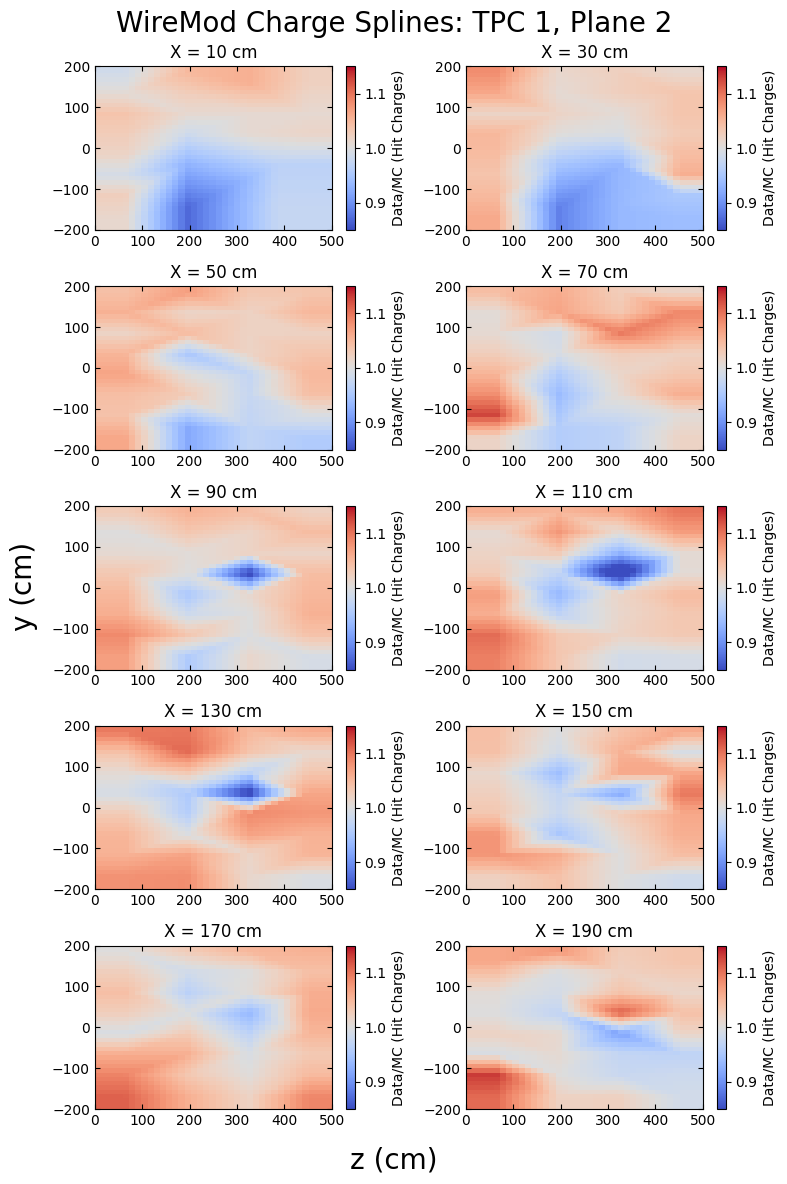

In [ ]:
fig, ax = plt.subplots(5, 2, figsize=(8, 12))
fig.supxlabel("z (cm)", fontsize=20)
fig.supylabel("y (cm)", fontsize=20)
if IsCharge:
    fig.suptitle(f"WireMod Charge Splines: TPC {TPC}, Plane {PLANE}", fontsize=20)
    plot_splines_x_dep(fig, ax, f, IDX, zlabel="Data/MC (Hit Charges)", r=[0.85, 1.15], transpose=True)
    plt.savefig(Figure_Dir + f"splines_xyzq_tpc{TPC}_plane{PLANE}.png", bbox_inches="tight")
else:
    fig.suptitle(f"WireMod Width Splines: TPC {TPC}, Plane {PLANE}", fontsize=20)
    plot_splines_x_dep(fig, ax, f, IDX, zlabel="Data/MC (Hit Widths)", r=[0.85, 1.15], transpose=True)
    plt.savefig(Figure_Dir + f"splines_xyzw_tpc{TPC}_plane{PLANE}.png", bbox_inches="tight")

plt.show()